## Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

** A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks.
It predicts outcomes by splitting data into smaller subsets based on feature values.
Structure of a Decision Tree
-Root Node:
The top-most node representing the entire dataset.
-Decision Nodes:
Nodes where the dataset is split based on specific conditions.
-Leaf Nodes:
The final nodes that contain the prediction or decision.

-Real-Life Example
Suppose a bank wants to predict whether a customer will subscribe to a term deposit.
Root Node: Is the customer's balance greater than ₹50,000?
Decision Node: Has the customer subscribed before?
Leaf Node: Yes or No
The tree follows these conditions and makes the final prediction.

## Q2. Differentiate between Gini Impurity and Entropy. Which one is used by default in Scikit-Learn and why?

** Gini Impurity and Entropy are measures used in Decision Trees to determine the best feature for splitting the data.
Gini Impurity measures the probability of incorrectly classifying a randomly selected data point.
Entropy measures the amount of uncertainty or randomness present in the dataset.
Gini Impurity is simpler and faster to calculate because it does not involve logarithmic computations.
Entropy is slightly more computationally expensive because it uses logarithmic calculations.
Both methods usually produce similar results in terms of model performance.
In Scikit-Learn, Gini Impurity is used as the default criterion.
The main reason for using Gini by default is that it is computationally efficient and faster while providing accuracy comparable to Entropy.

## Q3. What is Overfitting in Decision Trees? How can we detect it using training and testing accuracy?

** Overfitting occurs when a Decision Tree learns the training data too well, including noise and outliers.
As a result, it performs very well on training data but poorly on unseen test data.
Detection
If:
Training Accuracy = 99%
Testing Accuracy = 80%
The model is likely overfitting because there is a large gap between training and testing performance.

## Q4. Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?

** Pruning is the process of reducing the size of a Decision Tree to avoid overfitting.
Pre-Pruning
Stops the tree from growing too large during training.
Examples:
max_depth
min_samples_split
Post-Pruning
Allows the tree to grow fully and then removes unnecessary branches.
Difference
--Pre-Pruning	           --Post-Pruning
.Stops growth early	     .Removes branches later
.Faster	                 .More accurate
.Simpler implementation	 .Better optimization

Pruning helps improve model performance on unseen data.

## Q5. What is Feature Importance? How can it help businesses in decision-making?

** Feature Importance shows how much each feature contributes to the prediction made by the model.
For example, in the Bank Marketing dataset:
Duration = 45%
Balance = 20%
Age = 8%
This means duration has a stronger influence on customer subscription decisions.
Business Benefits:
-Identifies key factors affecting customer behavior.
-Helps focus marketing efforts.
-Improves decision-making.
-Reduces unnecessary features.

## Q6. Data Understanding
Load the dataset
Display first 5 rows
Check:
Shape
Data types
Column names
Interpret:
What types of variables are present?

In [13]:
import pandas as pd

df = pd.read_csv(r'C:\Users\soumy\Downloads\bank.csv')

In [14]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [15]:
df.shape

(11162, 17)

In [16]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [17]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

Interpretation
The dataset contains both numerical and categorical variables.
Numerical variables: age, balance, duration, campaign, pdays, previous, etc.
Categorical variables: job, marital, education, housing, loan, contact, month, etc.
Target variable: y (yes/no).

## Q7. Data Cleaning
Check for missing values
Handle missing values (if any)
Check for duplicates
Interpret:
Is the dataset clean? What issues did you find?

In [18]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [19]:
df = df.dropna()

In [20]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Interpretation
-No missing values and duplicates found dataset is clean.

## Q8. Data Preprocessing
Convert categorical variables into numerical
Mention which encoding method you used
Interpret:
Why is encoding necessary for Decision Trees?

In [21]:
from sklearn.preprocessing import LabelEncoder

data = df.copy()

le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

print(data.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   59    0        1          1        0     2343        1     0        2   
1   56    0        1          1        0       45        0     0        2   
2   41    9        1          1        0     1270        1     0        2   
3   55    7        1          1        0     2476        1     0        2   
4   54    0        1          2        0      184        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  deposit  
0    5      8      1042         1     -1         0         3        1  
1    5      8      1467         1     -1         0         3        1  
2    5      8      1389         1     -1         0         3        1  
3    5      8       579         1     -1         0         3        1  
4    5      8       673         2     -1         0         3        1  


Encoding Method Used
Label Encoding
-Interpretation
Decision Trees work with numerical values. Encoding converts text categories such as "married", "single", "yes", "no" into numbers so the algorithm can process them.

## Q9. Feature Selection & Splitting
Separate:
Features (X)
Target (y)
Perform train-test split (80-20)
Interpret:
Why is train-test split important?

In [23]:
from sklearn.model_selection import train_test_split

X = data.drop('deposit', axis=1)
y = data['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8929, 16)
Testing Shape: (2233, 16)


The dataset was divided into training and testing sets using an 80-20 split.
The training set is used to train the model while the testing set evaluates model performance on unseen data.
This helps in measuring the generalization ability of the model.

## Q10. Model Building
Train a Decision Tree Classifier
Use:
criterion='gini'
max_depth=5
Interpret:
What does max_depth control?

In [24]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


A Decision Tree Classifier was trained using Gini Impurity as the splitting criterion.
The max_depth parameter was set to 5 to control the depth of the tree and reduce overfitting.

## Q11. Model Evaluation 
Perform:
Accuracy score
Confusion Matrix
Classification Report
Interpret (MUST):
Is the model performing well?
Explain Precision & Recall
Any class imbalance issue?

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print("Accuracy Score")
print(accuracy_score(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("Classification Report")
print(classification_report(y_test, y_pred))

Accuracy Score
0.8051948051948052
Confusion Matrix
[[867 299]
 [136 931]]
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



The model performance was evaluated using Accuracy, Confusion Matrix and Classification Report.
Precision indicates how many predicted positive cases were actually positive.
Recall indicates how many actual positive cases were correctly identified.
The class distribution should also be examined to identify any imbalance issues.

## Q12. Overfitting Check
Calculate:
Training accuracy
Testing accuracy
Interpret:
Is the model overfitting or underfitting?

In [26]:
train_acc = model.score(X_train, y_train)

test_acc = model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8149848807257252
Testing Accuracy: 0.8051948051948052


Training and testing accuracies were compared to check for overfitting.
If training accuracy is significantly higher than testing accuracy, the model may be overfitting.
A small difference indicates good generalization.

## Q13. Pruning Experiment
Train another model with:
max_depth=3
min_samples_split=20
Interpret:
Compare performance with previous model
Which one is better and why?

In [27]:
pruned_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

pruned_model.fit(X_train, y_train)

pruned_pred = pruned_model.predict(X_test)

print("Pruned Model Accuracy")
print(accuracy_score(y_test, pruned_pred))

Pruned Model Accuracy
0.7653381101656964


A pruned Decision Tree was trained using a smaller depth and larger minimum split size.
The performance was compared with the original model.
The simpler model is preferred if it achieves similar accuracy because it generalizes better.

## Q14. Feature Importance
Extract top 5 important features
Plot feature importance graph
Interpret:
Which features influence prediction the most?

Top 5 Important Features
     Feature  Importance
11  duration    0.595239
8    contact    0.121729
13     pdays    0.084299
6    housing    0.067469
10     month    0.054023


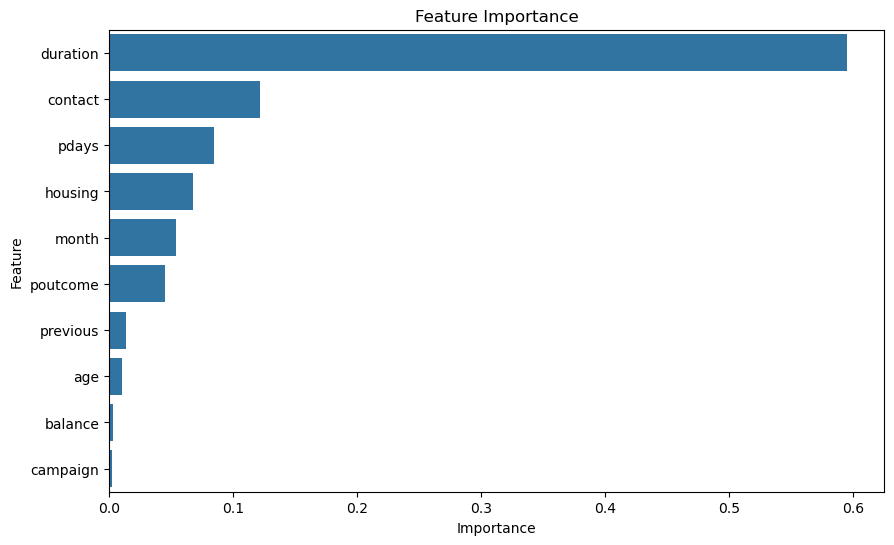

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 5 Important Features")
print(importance.head())

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Feature Importance")
plt.show()

Feature importance identifies which variables contribute most to prediction.
The top features have the highest influence on customer subscription decisions.
These features can help the bank focus its marketing efforts.

## Q15. Business Insights 
Based on your model:
Answer:
Which type of customers are more likely to say “yes”?
What strategy should a bank us

Customers with favorable previous campaign outcomes, higher balances and longer interaction durations are more likely to subscribe to a term deposit.

The bank should focus on these customer groups and use personalized marketing strategies to improve conversion rates. Feature importance analysis can be used to identify high-potential customers and optimize marketing campaigns.